# Model A — Topology-Aware Fault Isolation & "Phantom kW/TR" Costing for a Chiller Plant

**Dataset:** LBNL Fault Detection & Diagnostics Data Sets — *Simulated chiller plant* (Granderson et al., LBNL/PNNL, 2022, DOI [10.25984/1881324](https://dx.doi.org/10.25984/1881324)), plus its Brick-schema `.ttl` model.

**One-line idea:** instead of predicting load, find *which piece of equipment is actually broken* (not the 15 sensors downstream that look odd because of it), then put a ₹/day price on every fault so maintenance is ranked by money lost.

### Why this dataset (and not a Kaggle meter CSV)
| Need | Typical Kaggle building-energy CSV | LBNL chiller plant set |
|---|---|---|
| Equipment-level points (chillers, towers, pumps, valve) | Whole-building meter only | 77 points, 1-min, 1 year |
| Ground truth of *what is wrong* | None | 21 faulted runs (7 fault types × severities) + 1 fault-free run |
| Plant topology | None | Brick `.ttl` (equipment, points, `feeds` relations) |
| Counterfactual ("same day, no fault") | Impossible | Every file uses the same Chicago TMY weather → paired comparison |

The paired, same-weather design is what makes a *validated* energy-penalty estimate possible: we can check our model's "phantom kWh" against the true kWh difference between a faulty run and the fault-free run.

### The 7 fault types (Table 3/4 of the LBNL inventory)
| Fault | Severities | Where it physically lives |
|---|---|---|
| Chilled-water leaving temp sensor bias, Chiller 1 | −2, −1, +1, +2 °C | Chiller 1 |
| Condenser-water leaving temp sensor bias, Cooling tower 1 | −2, −1, +1, +2 °C | Cooling tower 1 |
| Secondary loop differential-pressure sensor bias | −20, −10, +10, +20 % | Secondary pumps / DP sensor |
| Condenser 3-way bypass valve leakage | 25, 50, 75 % | Bypass valve |
| Condenser 3-way bypass valve stuck | 50, 75 % | Bypass valve |
| Cooling tower 1 heat-exchanger fouling | 95, 80, 65 % of UA | Cooling tower 1 |
| Badly tuned PI loop, condenser supply temperature | — | Cooling-tower fan control |

### Why this technique
**The problem with flat anomaly detection.** A +1 °C bias on Chiller 1's leaving-water sensor makes Chiller 1 *overcool* (it is chasing a wrong reading), so the primary header temperature, the secondary supply temperature, chiller power, condenser heat and tower fan speed all shift. A model that learns "normal" from weather and load alone flags all of them — alarm fatigue — and cannot tell a sensor fault from real equipment degradation.

**What we do instead — graph-conditioned local residual models (learned analytical redundancy):**
1. Parse the Brick graph into a directed equipment graph (`feeds` edges between equipment, `hasPoint` from equipment to sensors).
2. For every equipment node, train a small gradient-boosting model per sensor that predicts that sensor **from the node's other sensors plus the sensors of the equipment that feeds it** (its graph parents), using fault-free data only.
   * A downstream node receives abnormal inputs but *responds normally to them* → small residual.
   * The node where the fault originates breaks its own physics → large residual.
3. **Root cause = the anomalous node with no anomalous parent** (highest score if several). One ticket instead of a page of alarms.
4. **Fault type** is then diagnosed by a classifier on the signed residual signature, tested on *severities it never saw in training*.
5. **Phantom kW/TR costing:** a fault-free plant-power model (weather + load only) gives the counterfactual kW; actual − counterfactual = phantom kW, converted to ₹/day and ranked with a payback estimate.

Gradient boosting (LightGBM) is used for the local models because the relations are smooth but non-linear (staging, valve saturation, fan-curve cubes), it needs no scaling, trains in seconds on 1 year of data, and is easy to audit (feature importances).

## 0. Setup
**Getting the real data (once):** open <https://faultdetection.lbl.gov/dataset/simulated-chiller-plant/>, fill in the short contributor form, and download *Simulated chiller plant data sets.zip* (22 CSVs) and the `.ttl` file.

**On Kaggle:** create a private Kaggle Dataset from the zip + `.ttl` (*Datasets → New Dataset*), then in this notebook use *Add Input* to attach it. The setup cell searches everything under `/kaggle/input`, so folder names don't matter. Turn *Internet* on in the notebook settings (needed to fetch the helper script from GitHub, and `rdflib` if the `.ttl` is attached). Set `REPO_URL` below to your repo.

**Locally / Colab:** put the CSVs in a folder called `data_lbnl_chiller` next to this notebook (or anywhere below the working folder).

Each 1-min file is averaged to 15-min as soon as it is read, so memory stays modest. A full run takes roughly 25–40 minutes on a 4-core CPU; no GPU needed.

If the CSVs are not found, the notebook falls back to `lbnl_surrogate.py` — a physics-based stand-in with the same 77 point names and 22 file names — so every cell can be tested end to end. **Numbers produced in that mode are not LBNL results.**

In [1]:
import re, glob, os, sys, subprocess, warnings, zlib
from pathlib import Path

# ------------------------------------------------------------------ CONFIG
REPO_URL = "https://github.com/GadiMahi/chiller-fdd-model-a"   # <- your GitHub repo (only needed on Kaggle/Colab)
RESAMPLE  = "15min"                      # 1-min raw data is averaged to 15-min
TARIFF_INR_PER_KWH = 9.0                 # ASSUMPTION - replace with the energy charge on your HT bill
# Illustrative repair costs (INR) for the payback column - replace with real quotes
REPAIR_COST_INR = {"chiller1_sensor_bias": 6000, "ct1_sensor_bias": 6000, "sec_dp_sensor_bias": 8000,
                   "valve_leakage": 45000, "valve_stuck": 35000, "ct1_fouling": 60000, "ct_pi_tuning": 10000}
SEED = 42

ON_KAGGLE = Path("/kaggle/input").exists()
# Where to look for the 22 LBNL CSVs and the Brick .ttl: on Kaggle, anywhere inside attached datasets
SEARCH = [Path("/kaggle/input")] if ON_KAGGLE else [Path("data_lbnl_chiller"), Path(".")]
def find(pattern):
    hits = {}
    for root in SEARCH:
        if root.exists():
            for p in root.rglob(pattern):
                if "data_surrogate" not in p.parts: hits.setdefault(p.name, p)   # de-duplicate by file name
    return sorted(hits.values())

# helper module for the stand-in data: fetch it from the repo if this notebook was opened on its own
if Path("lbnl_surrogate.py").exists():
    sys.path.insert(0, str(Path.cwd()))
elif not any(Path(p, "lbnl_surrogate.py").exists() for p in sys.path if p):
    if not Path("repo").exists():
        subprocess.run(["git", "clone", "-q", "--depth", "1", REPO_URL, "repo"], check=False)
    sys.path.insert(0, str(Path("repo").resolve()))

for mod, pipname in [("lightgbm", "lightgbm"), ("networkx", "networkx")]:
    try: __import__(mod)
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", pipname])

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import lightgbm as lgb
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score
warnings.filterwarnings("ignore")
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})

csvs = [str(p) for p in find("ChillerPlant*.csv")]
ttls = find("*.ttl")
TTL_PATH = ttls[0] if ttls else Path("no_ttl_found.ttl")
if len(csvs) >= 22:
    MODE = "REAL LBNL DATA"
    DATA_DIR = Path(csvs[0]).parent
else:
    # Fallback for development only: physics-based stand-in with identical point & file names
    from lbnl_surrogate import build_all
    DATA_DIR = Path("data_surrogate")
    if len(glob.glob(str(DATA_DIR / "*.csv"))) < 22:
        build_all(DATA_DIR)
    csvs = sorted(glob.glob(str(DATA_DIR / "*.csv")))
    MODE = "SURROGATE (stand-in data - do not quote these numbers)"
if TTL_PATH.exists():
    try: import rdflib
    except ImportError: subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rdflib"])
print("MODE:", MODE, "|", len(csvs), "files in", DATA_DIR, "| Brick .ttl:", TTL_PATH if TTL_PATH.exists() else "not found")

MODE: SURROGATE (stand-in data - do not quote these numbers) | 22 files in data_surrogate


## 1. Load, harmonise and label the 22 runs

In [2]:
FAULT_RULES = [  # (regex on file name, fault label, severity parser)
    (r"chiller_bias_(-?\d+)",                         "chiller1_sensor_bias", lambda m: float(m.group(1))),
    (r"coolingtower_bias_(-?\d+)",                    "ct1_sensor_bias",      lambda m: float(m.group(1))),
    (r"pressure_bias_(-?\d+)",                        "sec_dp_sensor_bias",   lambda m: float(m.group(1)) / 100),
    (r"bypass_leakage_(\d+)",                         "valve_leakage",        lambda m: float(m.group(1)) / 100),
    (r"bypass_stuck_(\d+)",                           "valve_stuck",          lambda m: float(m.group(1)) / 100),
    (r"coolingtower_fouling_(\d+)",                   "ct1_fouling",          lambda m: float(m.group(1)) / 100),
    (r"coolingtower_PI",                              "ct_pi_tuning",         lambda m: 1.0),
]
def label_file(path):
    name = Path(path).name
    for rx, lab, sev in FAULT_RULES:
        m = re.search(rx, name)
        if m: return lab, sev(m)
    return "fault_free", 0.0

def norm_col(c):
    c = str(c).strip().upper().replace(" ", "_")
    return re.sub(r"_(\d)$", r"\1", c)          # CHL_POW_1 -> CHL_POW1

def load_run(path):
    df = pd.read_csv(path, low_memory=False)
    # time column: first column that parses as datetime, else build a 1-min index (data start 1 h after Jan-1 00:00)
    tcol = None
    for c in df.columns[:3]:
        if not pd.api.types.is_numeric_dtype(df[c]):
            try:
                pd.to_datetime(df[c].iloc[:50]); tcol = c; break
            except Exception: pass
    if tcol is not None:
        idx = pd.to_datetime(df.pop(tcol))
    else:
        idx = pd.date_range("2019-01-01 01:00", periods=len(df), freq="1min")
    df.index = idx
    df.columns = [norm_col(c) for c in df.columns]
    df = df.apply(pd.to_numeric, errors="coerce").astype("float32")
    return df.resample(RESAMPLE).mean()

runs = {}
for p in csvs:
    lab, sev = label_file(p)
    runs[Path(p).name] = dict(fault=lab, sev=sev, df=load_run(p))
RAW_COLS = list(runs[next(iter(runs))]["df"].columns)
inv = pd.DataFrame([(k, v["fault"], v["sev"], v["df"].shape[0], v["df"].shape[1]) for k, v in runs.items()],
                   columns=["file", "fault", "severity", "rows", "points"])
FF = [k for k, v in runs.items() if v["fault"] == "fault_free"][0]
inv.sort_values(["fault", "severity"]).reset_index(drop=True)

,file,fault,severity,rows,points
0,ChillerPlant_chiller_bias_-2.csv,chiller1_sensor_bias,-2.00,35036,77
1,ChillerPlant_chiller_bias_-1.csv,chiller1_sensor_bias,-1.00,35036,77
2,ChillerPlant_chiller_bias_1.csv,chiller1_sensor_bias,1.00,35036,77
3,ChillerPlant_chiller_bias_2.csv,chiller1_sensor_bias,2.00,35036,77
4,ChillerPlant_coolingtower_fouling_065.csv,ct1_fouling,0.65,35036,77
5,ChillerPlant_coolingtower_fouling_080.csv,ct1_fouling,0.80,35036,77
6,ChillerPlant_coolingtower_fouling_095.csv,ct1_fouling,0.95,35036,77
7,ChillerPlant_coolingtower_bias_-2.csv,ct1_sensor_bias,-2.00,35036,77
8,ChillerPlant_coolingtower_bias_-1.csv,ct1_sensor_bias,-1.00,35036,77
9,ChillerPlant_coolingtower_bias_1.csv,ct1_sensor_bias,1.00,35036,77


In [3]:
# Derived plant quantities (units in the data: degF, GPM, W for loads, kW for power)
W_PER_TR = 3516.85
def add_derived(df):
    d = df.copy()
    d["P_CHILLERS"] = d.filter(regex=r"^CHL_POW\d$").sum(axis=1)
    d["P_TOWERS"]   = d.filter(regex=r"^CT_POW\d$").sum(axis=1)
    d["P_PUMPS"]    = d.filter(regex=r"^(CDWL_PM_POW|CWL_PRI_PM_POW|CWL_SEC_PM_POW)\d$").sum(axis=1)
    d["P_PLANT"]    = d[["P_CHILLERS", "P_TOWERS", "P_PUMPS"]].sum(axis=1)
    d["LOAD_TR"]    = d["CWL_SEC_LOAD"].clip(lower=0) / W_PER_TR
    d["N_CHL"]      = d.filter(regex=r"^CHL_STA\d$").round().sum(axis=1)
    d["PLANT_ON"]   = (d["N_CHL"] >= 0.5) & (d["LOAD_TR"] > 5)
    d["KW_PER_TR"]  = np.where(d["PLANT_ON"], d["P_PLANT"] / d["LOAD_TR"].clip(lower=1), np.nan)
    d["CT_APPROACH"]= d["CDWL_SW_TEMP"] - d["OA_TEMP_WB"]
    d["LIFT_F"]     = d.filter(regex=r"^CHL_SWCD_TEMP\d$").where(d.filter(regex=r"^CHL_STA\d$").values > .5).mean(axis=1) \
                      - d["CWL_PRI_SW_TEMP"]
    d["SEC_DT"]     = d["CWL_SEC_RW_TEMP"] - d["CWL_SEC_SW_TEMP"]
    d["HOUR"] = d.index.hour; d["DOW"] = d.index.dayofweek; d["DOY"] = d.index.dayofyear
    return d
for k in runs: runs[k]["df"] = add_derived(runs[k]["df"])
ff = runs[FF]["df"]
print(f"Fault-free run: plant on {ff.PLANT_ON.mean():.0%} of intervals, "
      f"peak load {ff.LOAD_TR.max():.0f} TR, annual plant energy {ff.P_PLANT.sum()*0.25/1e3:,.0f} MWh, "
      f"seasonal plant kW/TR {ff.P_PLANT[ff.PLANT_ON].sum()/ff.LOAD_TR[ff.PLANT_ON].sum():.3f}")

Fault-free run: plant on 55% of intervals, peak load 1101 TR, annual plant energy 1,270 MWh, seasonal plant kW/TR 0.819


## 2. Where the fault-free plant already wastes energy (EDA)
Before any fault: how efficient is the plant, and what drives kW/TR? This tells us which points matter and gives context for the fault penalties.

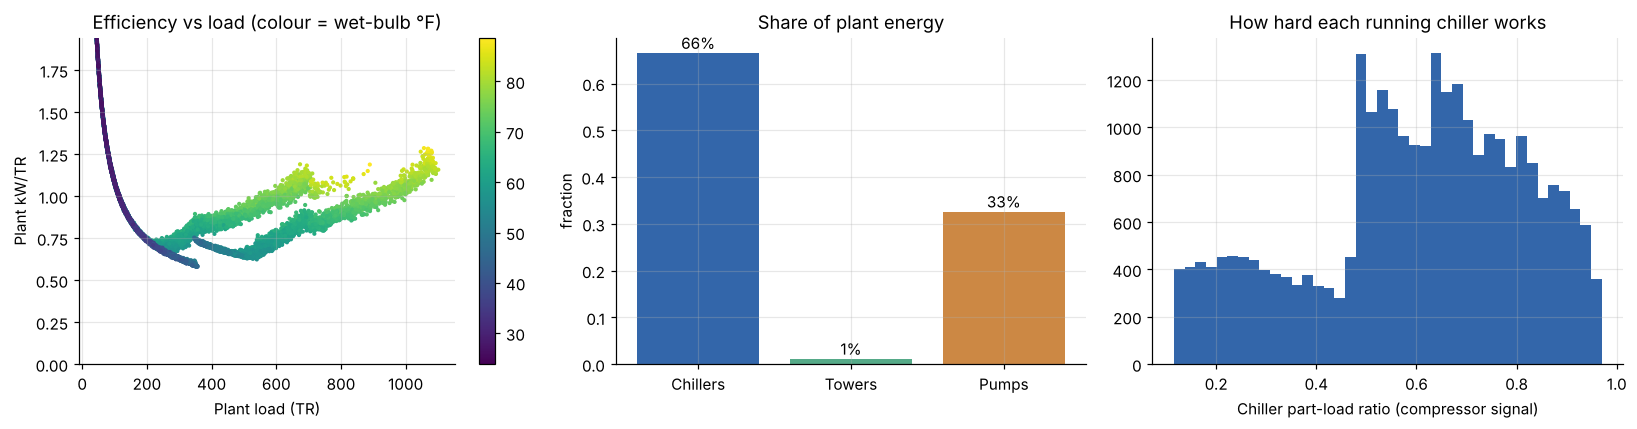

In [4]:
on = ff[ff.PLANT_ON]
fig, ax = plt.subplots(1, 3, figsize=(15, 4))
sc = ax[0].scatter(on.LOAD_TR, on.KW_PER_TR, c=on.OA_TEMP_WB, s=3, cmap="viridis")
ax[0].set(xlabel="Plant load (TR)", ylabel="Plant kW/TR", title="Efficiency vs load (colour = wet-bulb °F)")
ax[0].set_ylim(0, np.nanpercentile(on.KW_PER_TR, 99.5)); plt.colorbar(sc, ax=ax[0])
share = on[["P_CHILLERS", "P_TOWERS", "P_PUMPS"]].sum() / on.P_PLANT.sum()
ax[1].bar(["Chillers", "Towers", "Pumps"], share.values, color=["#3366aa", "#55aa88", "#cc8844"])
ax[1].set(title="Share of plant energy", ylabel="fraction")
for i, v in enumerate(share.values): ax[1].text(i, v + .01, f"{v:.0%}", ha="center")
# chiller-level part load ratio distribution when running
plr = pd.concat([on[f"CHL_COMP_SPD_CTRL{k}"][on[f"CHL_STA{k}"] > .5] for k in (1, 2, 3)])
ax[2].hist(plr, bins=40, color="#3366aa"); ax[2].set(xlabel="Chiller part-load ratio (compressor signal)", title="How hard each running chiller works")
plt.tight_layout(); plt.show()

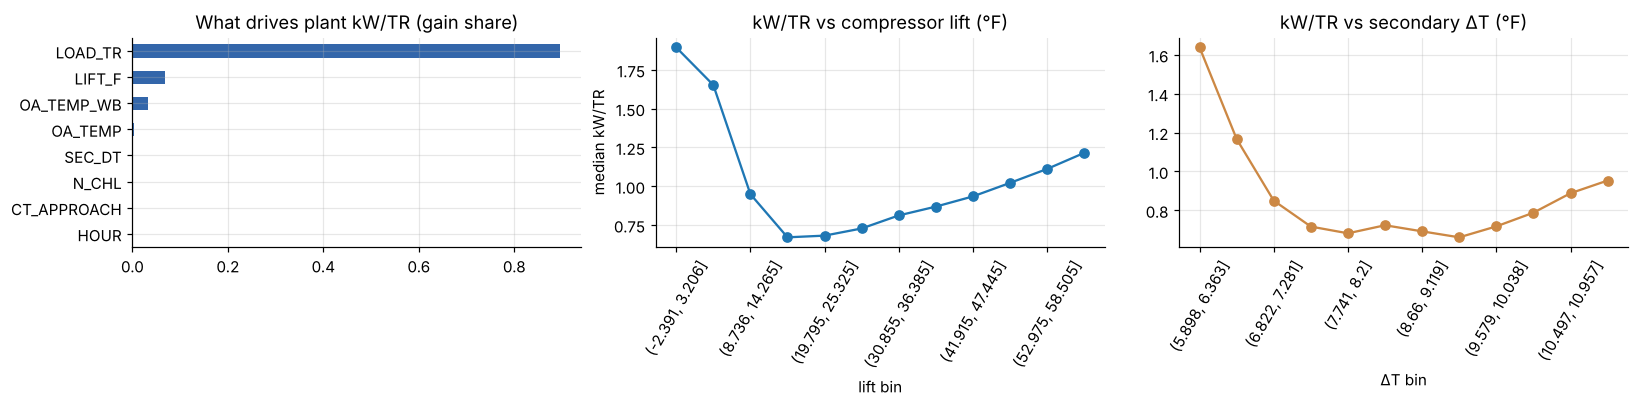

Hours with secondary ΔT < 8°F (design ~10°F, 'low ΔT syndrome'): 52% of operating time
Hours with tower approach > 10°F: 36%
Running chillers below 30% part load: 13% of chiller-hours


In [5]:
# Key drivers of plant kW/TR: gradient boosting + permutation-free gain importance, and binned effects
drv = ["LOAD_TR", "OA_TEMP_WB", "OA_TEMP", "N_CHL", "CT_APPROACH", "LIFT_F", "SEC_DT", "HOUR"]
X, y = on[drv].astype(float), on.KW_PER_TR.astype(float)
m = lgb.LGBMRegressor(n_estimators=300, learning_rate=.05, num_leaves=31, random_state=SEED, verbose=-1).fit(X, y)
imp = pd.Series(m.booster_.feature_importance("gain"), drv); imp = (imp / imp.sum()).sort_values()
fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
imp.plot.barh(ax=ax[0], color="#3366aa", title="What drives plant kW/TR (gain share)")
b = pd.cut(on.LIFT_F, 12); on.groupby(b, observed=True).KW_PER_TR.median().plot(ax=ax[1], marker="o")
ax[1].set(title="kW/TR vs compressor lift (°F)", xlabel="lift bin", ylabel="median kW/TR"); ax[1].tick_params(axis="x", rotation=60)
b = pd.cut(on.SEC_DT, 12); on.groupby(b, observed=True).KW_PER_TR.median().plot(ax=ax[2], marker="o", color="#cc8844")
ax[2].set(title="kW/TR vs secondary ΔT (°F)", xlabel="ΔT bin"); ax[2].tick_params(axis="x", rotation=60)
plt.tight_layout(); plt.show()
low_dt = (on.SEC_DT < 8).mean()
print(f"Hours with secondary ΔT < 8°F (design ~10°F, 'low ΔT syndrome'): {low_dt:.0%} of operating time")
print(f"Hours with tower approach > 10°F: {(on.CT_APPROACH > 10).mean():.0%}")
print(f"Running chillers below 30% part load: {(plr < .3).mean():.0%} of chiller-hours")

### What each fault costs — ground truth from the paired runs
Every run sees identical weather and building load, so *faulty energy − fault-free energy* at the same timestamp is the true penalty. This is the yardstick our deployable estimate (Section 6) is checked against.

In [6]:
rows = []
for k, v in runs.items():
    d = v["df"]; mask = ff.PLANT_ON
    dE = (d.P_PLANT - ff.P_PLANT)[mask].sum() * 0.25          # kWh over the year (15-min steps)
    rows.append(dict(file=k, fault=v["fault"], severity=v["sev"],
                     energy_change_pct=100 * dE / (ff.P_PLANT[mask].sum() * .25),
                     true_phantom_kWh_yr=dE,
                     chw_supply_shift_F=(d.CWL_SEC_SW_TEMP - ff.CWL_SEC_SW_TEMP)[mask].mean(),
                     cond_supply_shift_F=(d.CDWL_SW_TEMP - ff.CDWL_SW_TEMP)[mask].mean()))
truth = pd.DataFrame(rows).query("fault!='fault_free'").sort_values("energy_change_pct", ascending=False)
truth["true_INR_yr"] = truth.true_phantom_kWh_yr * TARIFF_INR_PER_KWH
truth.round(2).reset_index(drop=True)

,file,fault,severity,energy_change_pct,true_phantom_kWh_yr,chw_supply_shift_F,cond_supply_shift_F,true_INR_yr
0,ChillerPlant_chiller_bias_2.csv,chiller1_sensor_bias,2.00,8.19,104026.546875,-2.85,0.05,936239.062500
1,ChillerPlant_bypass_stuck_075.csv,valve_stuck,0.75,5.91,75019.843750,-0.00,-1.13,675178.625000
2,ChillerPlant_bypass_leakage_075.csv,valve_leakage,0.75,4.65,59119.078125,-0.00,1.31,532071.687500
3,ChillerPlant_coolingtower_fouling_065.csv,ct1_fouling,0.65,4.08,51858.218750,-0.00,0.20,466724.000000
4,ChillerPlant_secondary_chilled_water_pressure_...,sec_dp_sensor_bias,-0.20,4.00,50776.800781,-0.00,0.00,456991.250000
5,ChillerPlant_chiller_bias_1.csv,chiller1_sensor_bias,1.00,3.77,47950.261719,-1.42,0.03,431552.281250
6,ChillerPlant_bypass_stuck_050.csv,valve_stuck,0.50,3.22,40928.238281,-0.00,-2.21,368354.125000
7,ChillerPlant_bypass_leakage_050.csv,valve_leakage,0.50,2.61,33115.410156,-0.00,0.77,298038.687500
8,ChillerPlant_secondary_chilled_water_pressure_...,sec_dp_sensor_bias,-0.10,1.73,22019.599609,-0.00,0.00,198176.453125
9,ChillerPlant_coolingtower_fouling_080.csv,ct1_fouling,0.80,1.45,18430.390625,-0.00,0.06,165873.515625


Note the sign: some faults **save** energy (e.g. a negative Chiller-1 sensor bias makes the chiller deliver *warmer* water). Those are still faults — they push supply temperature up, which costs dehumidification and comfort — so the costing flags them as *comfort-risk* rather than ignoring them.

## 3. Brick topology → directed equipment graph
If the LBNL `.ttl` is present it is parsed with `rdflib` (`brick:feeds`, `brick:hasPart`, `brick:hasPoint` / `brick:isPointOf`). The parsed graph is used only if it maps most CSV columns to equipment; otherwise the topology documented in the LBNL inventory (Fig. 2) is used, written down in the same Brick vocabulary.

In [7]:
POINT_SETS = {   # equipment -> points (from Table 2 / Fig. 2 of the LBNL inventory)
    **{f"CT{k}": [f"CT_FLOW{k}", f"CT_RW_TEMP{k}", f"CT_SW_TEMP{k}", f"CT_FAN_SPD{k}", f"CT_FAN_SPD_CTRL{k}", f"CT_POW{k}", f"CT_STA{k}"] for k in (1, 2, 3)},
    "CDW_Bypass_Valve": ["TWV_CTRL"],
    "CDW_Supply_Header": ["CDWL_SW_TEMP", "CDWL_CW_FLOW", "CT_SW_TEMPSPT"],
    **{f"CDW_Pump{k}": [f"CDWL_PM_POW{k}"] for k in (1, 2, 3)},
    **{f"Chiller{k}": [f"CHL_COMP_SPD_CTRL{k}", f"CHL_CW_FLOW{k}", f"CHL_CD_FLOW{k}", f"CHL_RW_TEMP{k}", f"CHL_SW_TEMP{k}",
                       f"CHL_SWCD_TEMP{k}", f"CHL_RWCD_TEMP{k}", f"CHL_POW{k}", f"CHL_STA{k}"] for k in (1, 2, 3)},
    "CDW_Return_Header": ["CDWL_RW_TEMP"],
    **{f"CHW_Pri_Pump{k}": [f"CWL_PRI_PM_POW{k}"] for k in (1, 2, 3)},
    "CHW_Primary_Header": ["CWL_PRI_SW_TEMP", "CWL_PRI_RW_TEMP", "CWL_PRI_CW_FLOW", "CWL_PRI_SW_TEMPSPT"],
    "CHW_Sec_Pumps": ["CWL_SEC_PM_POW1", "CWL_SEC_PM_POW2", "CWL_SEC_PM_SPD1", "CWL_SEC_PM_SPD2",
                      "CWL_SEC_PM_STA1", "CWL_SEC_PM_STA2", "CWL_SEC_DP", "CWL_SEC_DPSPTS"],
    "CHW_Secondary_Loop": ["CWL_SEC_SW_TEMP", "CWL_SEC_RW_TEMP", "CWL_SEC_CW_FLOW", "CWL_SEC_LOAD"],
    "Weather": ["OA_TEMP", "OA_TEMP_WB"],
    "AHUs": [],
}
FEEDS = ([("Weather", f"CT{k}") for k in (1, 2, 3)] + [("Weather", "AHUs")] +
         [(f"CT{k}", "CDW_Bypass_Valve") for k in (1, 2, 3)] + [("CDW_Return_Header", "CDW_Bypass_Valve"),
          ("CDW_Bypass_Valve", "CDW_Supply_Header")] +
         [x for k in (1, 2, 3) for x in [("CDW_Supply_Header", f"CDW_Pump{k}"), (f"CDW_Pump{k}", f"Chiller{k}"),
                                         (f"Chiller{k}", "CDW_Return_Header"), ("CDW_Return_Header", f"CT{k}"),
                                         (f"Chiller{k}", "CHW_Primary_Header"), ("AHUs", f"CHW_Pri_Pump{k}"),
                                         (f"CHW_Pri_Pump{k}", f"Chiller{k}")]] +
         [("CHW_Primary_Header", "CHW_Sec_Pumps"), ("CHW_Sec_Pumps", "CHW_Secondary_Loop"), ("CHW_Secondary_Loop", "AHUs")])

def graph_from_ttl(path, columns):
    import rdflib
    g = rdflib.Graph(); g.parse(str(path), format="turtle")
    ln = lambda u: re.split(r"[#/]", str(u))[-1]
    G, pts = nx.DiGraph(), {}
    colset = {norm_col(c) for c in columns}
    for s, p, o in g:
        pn = ln(p)
        if pn == "feeds": G.add_edge(ln(s), ln(o))
        elif pn in ("hasPoint", "isPointOf"):
            eq, pt = (ln(s), ln(o)) if pn == "hasPoint" else (ln(o), ln(s))
            pt = norm_col(pt)
            if pt in colset: pts.setdefault(eq, []).append(pt)
    return G, pts

cols = runs[FF]["df"].columns
SOURCE = "documented LBNL topology"
if TTL_PATH.exists():
    try:
        G_ttl, P_ttl = graph_from_ttl(TTL_PATH, cols)
        covered = sum(len(v) for v in P_ttl.values())
        print(f".ttl parsed: {G_ttl.number_of_nodes()} equipment nodes, {G_ttl.number_of_edges()} feeds edges, {covered} points mapped")
        if covered >= 0.7 * 77 and G_ttl.number_of_edges() > 5:
            POINT_SETS, FEEDS, SOURCE = {**P_ttl, "Weather": ["OA_TEMP", "OA_TEMP_WB"]}, list(G_ttl.edges), "Brick .ttl"
    except Exception as e:
        print("ttl parse failed, using documented topology:", e)
G = nx.DiGraph(); G.add_nodes_from(POINT_SETS); G.add_edges_from(FEEDS)
POINT_SETS = {n: [p for p in POINT_SETS.get(n, []) if p in cols] for n in G.nodes}

# Hydraulic ownership: a water-flow sensor reports what a pump or valve *sets*, so its residual is scored at that
# actuator (e.g. tower flow -> bypass valve, chiller CHW flow -> its primary pump). Generic rule: the single pump/valve
# neighbour on the same water circuit; header totals stay where they are.
ACTUATOR = lambda n: bool(re.search(r"(Pump|Valve)", n, re.I))
FLOW_OWNER = {}
for n in G.nodes:
    if ACTUATOR(n) or re.search("Header", n, re.I): continue
    for p in POINT_SETS[n]:
        if "FLOW" not in p: continue
        act = [m for m in set(G.predecessors(n)) | set(G.successors(n)) if ACTUATOR(m)]
        if "_CD_" in p or p.startswith("CT_"): act = [m for m in act if "CDW" in m] or act
        elif "CHL_CW" in p or p.startswith("CWL_"): act = [m for m in act if "CHW" in m] or act
        if len(act) == 1: FLOW_OWNER[p] = act[0]
print("Flow sensors scored at their actuator:", FLOW_OWNER)
print(f"Graph source: {SOURCE} | {G.number_of_nodes()} nodes, {G.number_of_edges()} feeds edges, "
      f"{sum(map(len, POINT_SETS.values()))} points attached")

Flow sensors scored at their actuator: {'CT_FLOW1': 'CDW_Bypass_Valve', 'CT_FLOW2': 'CDW_Bypass_Valve', 'CT_FLOW3': 'CDW_Bypass_Valve', 'CHL_CW_FLOW1': 'CHW_Pri_Pump1', 'CHL_CD_FLOW1': 'CDW_Pump1', 'CHL_CW_FLOW2': 'CHW_Pri_Pump2', 'CHL_CD_FLOW2': 'CDW_Pump2', 'CHL_CW_FLOW3': 'CHW_Pri_Pump3', 'CHL_CD_FLOW3': 'CDW_Pump3', 'CWL_SEC_CW_FLOW': 'CHW_Sec_Pumps'}
Graph source: documented LBNL topology | 20 nodes, 33 feeds edges, 77 points attached


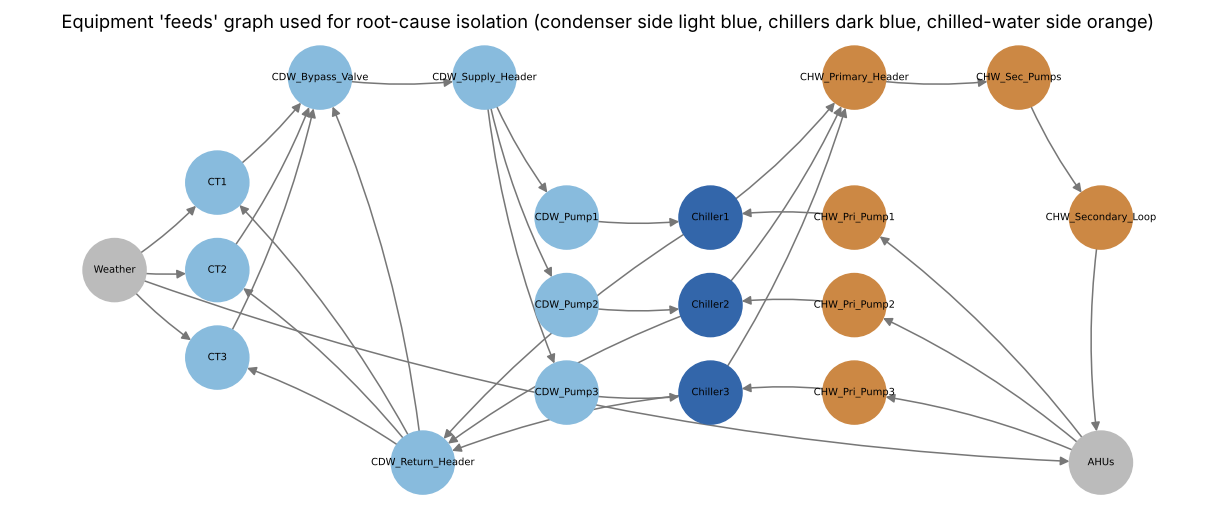

In [8]:
pos = {"Weather": (0, 3), "CT1": (1, 4), "CT2": (1, 3), "CT3": (1, 2), "CDW_Bypass_Valve": (2, 5.2), "CDW_Supply_Header": (3.6, 5.2),
       "CDW_Return_Header": (3, 0.8), **{f"CDW_Pump{k}": (4.4, 4.6 - k) for k in (1, 2, 3)}, **{f"Chiller{k}": (5.8, 4.6 - k) for k in (1, 2, 3)},
       **{f"CHW_Pri_Pump{k}": (7.2, 4.6 - k) for k in (1, 2, 3)}, "CHW_Primary_Header": (7.2, 5.2), "CHW_Sec_Pumps": (8.8, 5.2),
       "CHW_Secondary_Loop": (9.6, 3.6), "AHUs": (9.6, 0.8)}
pos = {n: pos.get(n, (np.random.rand() * 8, np.random.rand() * 5)) for n in G.nodes}
plt.figure(figsize=(14, 5.5))
col = ["#88bbdd" if n.startswith("CT") or "CDW" in n else "#3366aa" if n.startswith("Chiller") else "#cc8844" if "CHW" in n else "#bbbbbb" for n in G.nodes]
nx.draw_networkx(G, pos, node_color=col, node_size=1700, font_size=6.5, arrowsize=12, edge_color="#777", connectionstyle="arc3,rad=0.08")
plt.title("Equipment 'feeds' graph used for root-cause isolation (condenser side light blue, chillers dark blue, chilled-water side orange)")
plt.axis("off"); plt.show()

## 4. Graph-conditioned local models (fault-free training)
For each equipment node and each of its analog sensors (temperatures, powers, flows, speeds, DP, valve signal):

`sensor ≈ f( other sensors of the same node, sensors of the parent nodes in the graph, weather )`

* Trained on **fault-free data, alternate weeks** (odd ISO weeks train; weeks ≡ 0 mod 4 calibrate the z-scores and alarm thresholds; weeks ≡ 2 mod 4 are held out for testing) so every season appears in each split.
* Flow sensors are scored at the pump/valve that sets the flow (see the ownership rule above), and the on/off status of every chiller, tower and pump is given to every model as staging context.
* Setpoints are deliberately *not* inputs: a biased sensor that a controller drives onto its setpoint would otherwise look perfect.
* Residuals are aggregated per day and standardised by the fault-free validation spread → a daily **z-score per sensor** (`zmean` for sustained offsets, `zstd` for oscillation).

The **flat baseline** for comparison is the usual approach: each sensor predicted from weather, load and time only.

In [9]:
SKIP = re.compile(r"(_STA\d?$|TEMPSPT|DPSPTS)")
EXO = ["OA_TEMP", "OA_TEMP_WB", "HOUR", "DOW"]
STATUS_ALL = [c for c in RAW_COLS if re.search(r"_STA\d$", c)]
week = ff.index.isocalendar().week.values
TRAIN = (week % 2 == 1); VAL = ~TRAIN; CAL = (week % 4 == 0); TEST = (week % 4 == 2)
WEEK_SPLIT = lambda d, r: (d.index.isocalendar().week.values % 4) == r

def owner(n, p): return FLOW_OWNER.get(p, n)
def eff_preds(n):
    # pumps and valves are 'transparent' for water temperature: look through them to the equipment behind
    out = []
    for q in G.predecessors(n):
        out.append(q)
        if ACTUATOR(q): out += [r for r in G.predecessors(q) if r != n]
    return list(dict.fromkeys(out))
def node_inputs(n):
    ins = [p for q in eff_preds(n) for p in POINT_SETS.get(q, [])]
    return [c for c in dict.fromkeys(ins + POINT_SETS[n] + EXO + STATUS_ALL) if not re.search(r"(TEMPSPT|DPSPTS)", c)]

TARGETS = [(n, p) for n in G.nodes for p in POINT_SETS[n] if not SKIP.search(p) and n != "Weather"
           and ff.loc[ff.PLANT_ON, p].std() > 1e-6]
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
class LinBoost:
    # Ridge regression + gradient boosting on its residuals. The linear part carries the physics-like trend and
    # extrapolates when a fault pushes inputs outside the fault-free range (pure trees would predict a flat value
    # there and blame the wrong node); the boosted part captures the non-linear remainder inside the range.
    def __init__(self, **kw): self.kw = kw
    def fit(self, X, y):
        self.sc = StandardScaler().fit(X); Xs = np.nan_to_num(self.sc.transform(X))
        self.lin = Ridge(alpha=10.0).fit(Xs, y)
        self.gb = lgb.LGBMRegressor(**self.kw).fit(X, y - self.lin.predict(Xs)); return self
    def predict(self, X):
        return self.lin.predict(np.nan_to_num(self.sc.transform(X))) + self.gb.predict(X)

params = dict(n_estimators=250, learning_rate=.06, num_leaves=31, min_child_samples=30, subsample=.8, subsample_freq=1,
              colsample_bytree=.8, random_state=SEED, verbose=-1)
local_models, flat_models = {}, {}
trn = ff[ff.PLANT_ON & TRAIN]
for n, p in TARGETS:
    o = owner(n, p)
    xi = [c for c in dict.fromkeys(node_inputs(o) + (node_inputs(n) if o != n else []))
          if c != p and not (FLOW_OWNER.get(c) == o and o != n)]
    local_models[p] = (o, xi, LinBoost(**params).fit(trn[xi], trn[p]))
    xf = EXO + ["LOAD_TR"]
    flat_models[p] = (n, xf, LinBoost(**params).fit(trn[xf], trn[p]))
print(f"{len(local_models)} local + {len(flat_models)} flat sensor models trained on {len(trn):,} fault-free intervals")

64 local + 64 flat sensor models trained on 9,396 fault-free intervals


In [10]:
def daily_residual_stats(d, models):
    on = d[d.PLANT_ON]
    R = pd.DataFrame({p: on[p] - mdl.predict(on[xi]) for p, (n, xi, mdl) in models.items()}, index=on.index)
    g = R.groupby(R.index.date)
    cnt = g.size()
    keep = cnt[cnt >= 16].index            # days with >= 4 h of operation
    return g.mean().loc[keep], g.std().loc[keep]

def standardiser(models):
    mu, sd = daily_residual_stats(ff[CAL], models)
    return dict(m_mu=mu.mean(), m_sd=mu.std() + 1e-9, s_mu=sd.mean(), s_sd=sd.std() + 1e-9)

STD_L, STD_F = standardiser(local_models), standardiser(flat_models)
def zscores(d, models, S):
    mu, sd = daily_residual_stats(d, models)
    return (mu - S["m_mu"]) / S["m_sd"], (sd - S["s_mu"]) / S["s_sd"]

# fit quality of local models on fault-free validation weeks
v = ff[ff.PLANT_ON & VAL]
q = pd.DataFrame({p: dict(node=n, R2=1 - ((v[p] - mdl.predict(v[xi]))**2).mean() / v[p].var(),
                          R2_flat=1 - ((v[p] - flat_models[p][2].predict(v[flat_models[p][1]]))**2).mean() / v[p].var())
                  for p, (n, xi, mdl) in local_models.items()}).T
print("Median validation R² - local (graph) models: %.3f | flat models: %.3f" % (q.R2.astype(float).median(), q.R2_flat.astype(float).median()))
# pump power at constant speed is flat noise (R² ≈ 0 is expected there), so summarise by node
q.astype({"R2": float, "R2_flat": float}).groupby("node")[["R2", "R2_flat"]].median().round(3).T

Median validation R² - local (graph) models: 1.000 | flat models: 0.986


node,CDW_Bypass_Valve,CDW_Pump1,CDW_Pump2,CDW_Pump3,CDW_Return_Header,CDW_Supply_Header,CHW_Pri_Pump1,CHW_Pri_Pump2,CHW_Pri_Pump3,CHW_Primary_Header,CHW_Sec_Pumps,CHW_Secondary_Loop,CT1,CT2,CT3,Chiller1,Chiller2,Chiller3
R2,1.000,-0.051,1.000,1.00,1.000,1.000,-0.046,1.000,1.00,0.999,1.000,0.999,1.000,1.000,1.000,0.999,1.000,1.000
R2_flat,0.993,-0.059,0.987,0.96,0.996,0.991,-0.047,0.987,0.96,0.985,0.976,0.995,0.981,0.991,0.983,0.989,0.992,0.981


## 5. Detection, root-cause isolation and alarm load
**Node score** for a day = largest |z| among that node's sensors (offset or oscillation). Scores are smoothed with a 3-operating-day rolling median (a real fault persists; noise does not). A node is *anomalous* if its smoothed score exceeds 1.5 × the highest value seen on fault-free calibration days. **Root cause** = the anomalous node that no other anomalous node explains — explained either by an anomalous node *upstream* of it (looking through pumps and valves), or by the pump/valve that is feeding it an abnormal flow. The code cell spells out how hydraulic loops are handled.
Evaluation uses only the held-out test weeks of every run, so no day used to train or calibrate is used to score.

In [11]:
node_of = {p: n for p, (n, _, _) in local_models.items()}
def node_scores(zm, zs):
    s = pd.concat([zm.abs(), zs.clip(lower=0)], axis=1)
    return s.T.groupby(lambda p: node_of[p]).max().T

smooth = lambda sc: sc.rolling(3, min_periods=1).median()
ZM_FF, ZS_FF = zscores(ff[CAL], local_models, STD_L)
THR = smooth(node_scores(ZM_FF, ZS_FF)).max() * 1.5

FLOWS_ON = {n: [p for p in POINT_SETS[n] if p in FLOW_OWNER] for n in G.nodes}
def isolate(scores, flat_zm):
    # Which anomalous node is the CAUSE?  q is a candidate cause of n if
    #   (a) q is upstream of n (looking through pumps/valves), or
    #   (b) q is the pump/valve that sets a flow into n and that flow is abnormal for the weather/load ("flow victim").
    # A flow victim is always explained by its actuator and cannot itself explain that actuator.
    # In hydraulic loops two nodes can be causes of each other; then the one with the larger anomaly is kept.
    # Root cause = anomalous node left unexplained; if several, the largest score/threshold wins.
    scores = smooth(scores); fz = smooth(flat_zm.abs()); out = []
    for day, s in scores.iterrows():
        r = s / THR[s.index]
        anom = set(r.index[r > 1])
        if not anom: out.append((day, None, 0.0)); continue
        victim = {n: {FLOW_OWNER[p] for p in FLOWS_ON.get(n, []) if FLOW_OWNER[p] in anom and fz.at[day, p] > 3} for n in anom}
        C = {n: {q for q in eff_preds(n) if q in anom and n not in victim.get(q, set()) and q not in victim[n]} | victim[n]
             for n in anom}
        def explained(n):
            return bool(victim[n]) or any(not (n in C.get(q, set()) and r[n] > r[q]) for q in C[n])
        roots = [n for n in anom if not explained(n)] or list(anom)
        rt = max(roots, key=lambda n: r[n]); out.append((day, rt, r[rt]))
    return pd.DataFrame(out, columns=["day", "root", "strength"]).set_index("day")

TRUE_NODE = {"chiller1_sensor_bias": {"Chiller1"}, "ct1_sensor_bias": {"CT1"}, "ct1_fouling": {"CT1"},
             "sec_dp_sensor_bias": {"CHW_Sec_Pumps"}, "valve_leakage": {"CDW_Bypass_Valve"}, "valve_stuck": {"CDW_Bypass_Valve"},
             "ct_pi_tuning": {"CT1", "CT2", "CT3", "CDW_Bypass_Valve"}}

EV, Z = [], {}
for k, v in runs.items():
    d = v["df"]; dv = d[WEEK_SPLIT(d, 2)]
    zm, zs = zscores(dv, local_models, STD_L); fzm, fzs = zscores(dv, flat_models, STD_F)
    Z[k] = (zm, zs)
    iso = isolate(node_scores(zm, zs), fzm)
    flat_alarms = ((fzm.abs() > 3) | (fzs > 3)).sum(axis=1)
    local_alarms = ((zm.abs() > 3) | (zs > 3)).sum(axis=1)
    for day in iso.index:
        EV.append(dict(file=k, fault=v["fault"], sev=v["sev"], day=day, root=iso.loc[day, "root"],
                       detected=iso.loc[day, "root"] is not None, flat_alarm_points=flat_alarms.get(day, 0),
                       local_alarm_points=local_alarms.get(day, 0)))
EV = pd.DataFrame(EV); EV["detected"] = EV.root.notna()
EV["root_correct"] = [r in TRUE_NODE.get(f, set()) for r, f in zip(EV.root, EV.fault)]
fa = EV[EV.fault == "fault_free"].detected.mean()
summ = EV[EV.fault != "fault_free"].groupby(["fault", "sev"]).agg(
    days=("day", "size"), detection_rate=("detected", "mean"),
    isolation_acc_when_detected=("root_correct", lambda s: s[EV.loc[s.index, "detected"]].mean()),
    flat_alarm_pts_per_day=("flat_alarm_points", "mean"), graph_tickets_per_day=("detected", "mean"))
print(f"False-alarm rate on held-out fault-free days: {fa:.1%}")
summ.round(2)

False-alarm rate on held-out fault-free days: 8.2%


days  detection_rate  isolation_acc_when_detected  flat_alarm_pts_per_day  graph_tickets_per_day
fault                sev                                                                                                    
chiller1_sensor_bias -2.00    73             1.0                         1.00                   25.85                    1.0
                     -1.00    73             1.0                         1.00                   20.42                    1.0
                      1.00    73             1.0                         0.97                   23.30                    1.0
                      2.00    73             1.0                         1.00                   29.99                    1.0
ct1_fouling           0.65    73             1.0                         0.21                   12.58                    1.0
                      0.80    73             1.0                         0.52                   10.26                    1.0
                      0.95    73             1.0                         0.71                    8.01                    1.0
ct1_sensor_bias      -2.00    73             1.0                         0.82                   14.32                    1.0
                     -1.00    73             1.0                         0.75                   13.26                    1.0
                      1.00    73             1.0                         0.52                   13.59                    1.0
                      2.00    73             1.0                         0.36                   14.37                    1.0
ct_pi_tuning          1.00    73             1.0                         1.00                   13.88                    1.0
sec_dp_sensor_bias   -0.20    73             1.0                         1.00                    6.60                    1.0
                     -0.10    73             1.0                         1.00                    5.99                    1.0
                      0.10    73             1.0                         0.99                    6.44                    1.0
                      0.20    73             1.0                         1.00                    6.45                    1.0
valve_leakage         0.25    73             1.0                         0.60                   13.12                    1.0
                      0.50    73             1.0                         0.55                   15.78                    1.0
                      0.75    73             1.0                         0.59                   16.47                    1.0
valve_stuck           0.50    73             1.0                         0.59                   17.26                    1.0
                      0.75    73             1.0                         0.55                   17.74                    1.0

Overall detection rate: 100.0% | correct root equipment when detected: 74.9%
Alarm load on detected fault days - flat detector: 14.6 sensors flagged/day -> graph isolation: 1 ticket/day


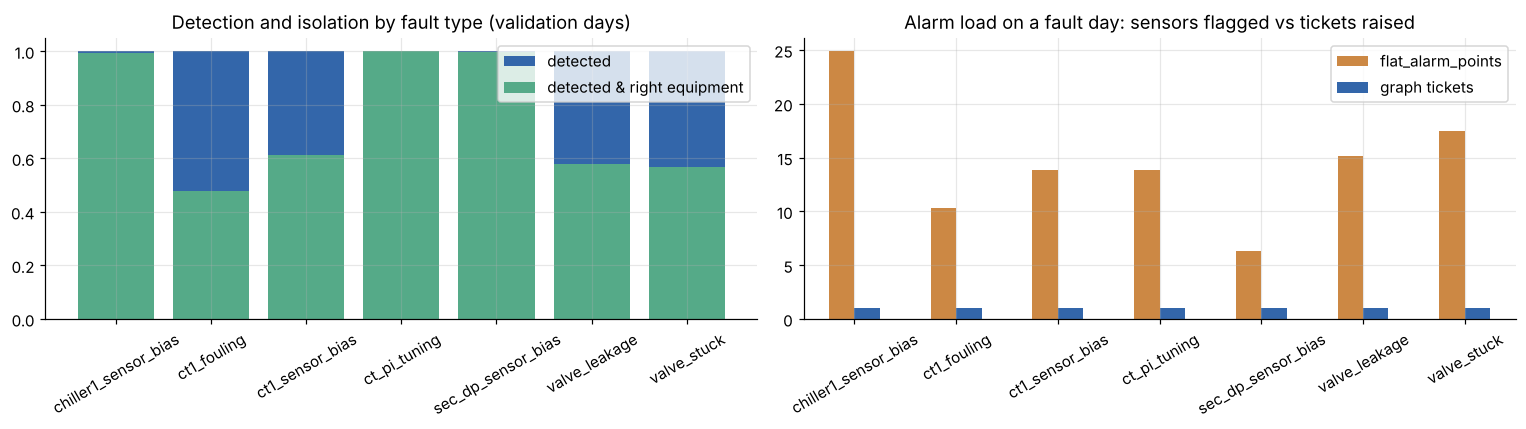

In [12]:
det = EV[EV.fault != "fault_free"]
dd = det[det.detected]
print(f"Overall detection rate: {det.detected.mean():.1%} | correct root equipment when detected: {dd.root_correct.mean():.1%}")
print(f"Alarm load on detected fault days - flat detector: {dd.flat_alarm_points.mean():.1f} sensors flagged/day "
      f"-> graph isolation: 1 ticket/day")
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
g = det.groupby("fault")
ax[0].bar(g.groups.keys(), g.detected.mean(), color="#3366aa", label="detected")
ax[0].bar(g.groups.keys(), dd.groupby("fault").root_correct.mean().reindex(g.groups.keys()).fillna(0) * g.detected.mean(),
          color="#55aa88", label="detected & right equipment")
ax[0].set(title="Detection and isolation by fault type (validation days)", ylim=(0, 1.05)); ax[0].legend(); ax[0].tick_params(axis="x", rotation=30)
a = dd.groupby("fault")[["flat_alarm_points"]].mean(); a["graph tickets"] = 1
a.plot.bar(ax=ax[1], color=["#cc8844", "#3366aa"]); ax[1].set(title="Alarm load on a fault day: sensors flagged vs tickets raised", xlabel="")
ax[1].tick_params(axis="x", rotation=30); plt.tight_layout(); plt.show()

### Fault-type diagnosis on *unseen severities*
Same equipment can fail in different ways (CT1 sensor bias vs CT1 fouling; valve leaking vs stuck). A LightGBM classifier on the **signed** local residual signature (daily `zmean`, `zstd` per sensor) names the fault type.
Test protocol: for each faulty run, train on every *other* run and test on this one — so the model is always judged on a severity it has never seen. Fault-free and PI-tuning (single file each) use the train-week/validation-week split instead.
The same protocol is run on **flat features** (raw daily means and std of all 77 points) for comparison.

In [13]:
def feat_graph(k, weeks):
    d = runs[k]["df"]; d = d[np.isin(d.index.isocalendar().week.values % 2, weeks)]
    zm, zs = zscores(d, local_models, STD_L)
    return pd.concat([zm.add_suffix("_zm"), zs.add_suffix("_zs")], axis=1)
def feat_flat(k, weeks):
    d = runs[k]["df"]; d = d[np.isin(d.index.isocalendar().week.values % 2, weeks) & d.PLANT_ON]
    base = d[[c for c in RAW_COLS if c in d.columns]]
    g = base.groupby(base.index.date); cnt = g.size(); keep = cnt[cnt >= 16].index
    return pd.concat([g.mean().add_suffix("_m"), g.std().add_suffix("_s")], axis=1).loc[keep]

def run_protocol(feat_fn):
    F = {k: {w: feat_fn(k, [w]) for w in (0, 1)} for k in runs}
    preds = []
    for k, v in runs.items():
        single = v["fault"] in ("fault_free", "ct_pi_tuning")
        Xtr = pd.concat([F[j][w] for j in runs for w in (0, 1) if (j != k) or (single and w == 1)])
        ytr = np.concatenate([[runs[j]["fault"]] * len(F[j][w]) for j in runs for w in (0, 1) if (j != k) or (single and w == 1)])
        Xte = F[k][0]
        clf = lgb.LGBMClassifier(n_estimators=300, learning_rate=.05, num_leaves=15, min_child_samples=10,
                                 class_weight="balanced", random_state=SEED, verbose=-1).fit(Xtr, ytr)
        p = clf.predict(Xte[Xtr.columns])
        preds += [(k, v["fault"], v["sev"], pi) for pi in p]
    return pd.DataFrame(preds, columns=["file", "true", "sev", "pred"])

P_graph, P_flat = run_protocol(feat_graph), run_protocol(feat_flat)
res = pd.DataFrame({
    "graph-residual features": [accuracy_score(P_graph.true, P_graph.pred), f1_score(P_graph.true, P_graph.pred, average="macro")],
    "flat raw features": [accuracy_score(P_flat.true, P_flat.pred), f1_score(P_flat.true, P_flat.pred, average="macro")]},
    index=["accuracy (unseen severity)", "macro-F1"])
res.round(3)

,graph-residual features,flat raw features
accuracy (unseen severity),0.707,0.561
macro-F1,0.655,0.520


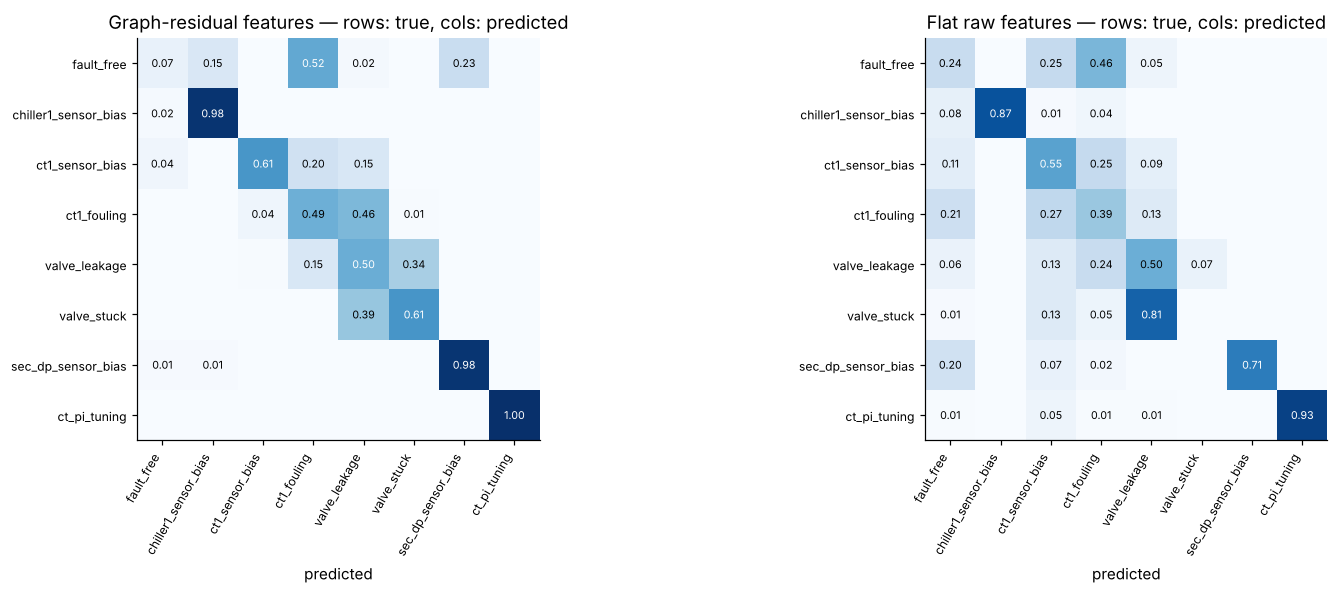

sev                   -2.00  -1.00  -0.20  -0.10   0.00   0.10   0.20   0.25   0.50   0.65   0.75   0.80   0.95   1.00   2.00
true                                                                                                                         
chiller1_sensor_bias    1.0   1.00    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.94   0.99
ct1_fouling             NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    0.8    NaN   0.68    0.0    NaN    NaN
ct1_sensor_bias         1.0   0.83    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   0.00   0.59
ct_pi_tuning            NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN   1.00    NaN
fault_free              NaN    NaN    NaN    NaN   0.07    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN    NaN
sec_dp_sensor_bias      NaN    NaN    1.0    1.0    NaN   0.92    1.0    NaN    NaN    NaN    NaN    NaN    NaN    NaN

In [14]:
labs = ["fault_free", "chiller1_sensor_bias", "ct1_sensor_bias", "ct1_fouling", "valve_leakage", "valve_stuck", "sec_dp_sensor_bias", "ct_pi_tuning"]
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
for a, (P, t) in zip(ax, [(P_graph, "Graph-residual features"), (P_flat, "Flat raw features")]):
    cm = confusion_matrix(P.true, P.pred, labels=labs, normalize="true")
    a.imshow(cm, cmap="Blues", vmin=0, vmax=1)
    a.set_xticks(range(len(labs)), labs, rotation=60, ha="right", fontsize=8); a.set_yticks(range(len(labs)), labs, fontsize=8)
    for i in range(len(labs)):
        for j in range(len(labs)):
            if cm[i, j] > .005: a.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7, color="white" if cm[i, j] > .5 else "black")
    a.set(title=f"{t} — rows: true, cols: predicted", xlabel="predicted"); a.grid(False)
plt.tight_layout(); plt.show()
print(P_graph.assign(ok=P_graph.true == P_graph.pred).groupby(["true", "sev"]).ok.mean().unstack().round(2))

## 6. Phantom kW/TR costing
A fault-free **plant power model** gives the counterfactual "what would this plant draw today without the fault". Its inputs must be things a fault cannot change. A tempting choice is measured cooling load (TR) — but load is *not* fault-proof: a chiller overcooling its water also removes extra moisture, so measured TR rises with the fault and hides part of the penalty. Two baselines are compared below: (A) weather + load + time, (B) weather + time only. On faulty data,

* `phantom kW = measured plant kW − model kW` and `phantom kW/TR = phantom kW / load TR`
* `₹/day = Σ phantom kW × 0.25 h × tariff` (15-min steps)

The model is first checked against ASHRAE Guideline 14 calibration limits on fault-free validation weeks (hourly CV(RMSE) < 30 %, |NMBE| < 10 %), then its annual phantom kWh per fault is compared with the paired ground truth from Section 2.

Baseline A: weather + load + time   hourly CV(RMSE) =  3.8%, NMBE = +0.40% -> meets ASHRAE Guideline 14


Baseline B: weather + time          hourly CV(RMSE) =  7.2%, NMBE = -0.27% -> meets ASHRAE Guideline 14


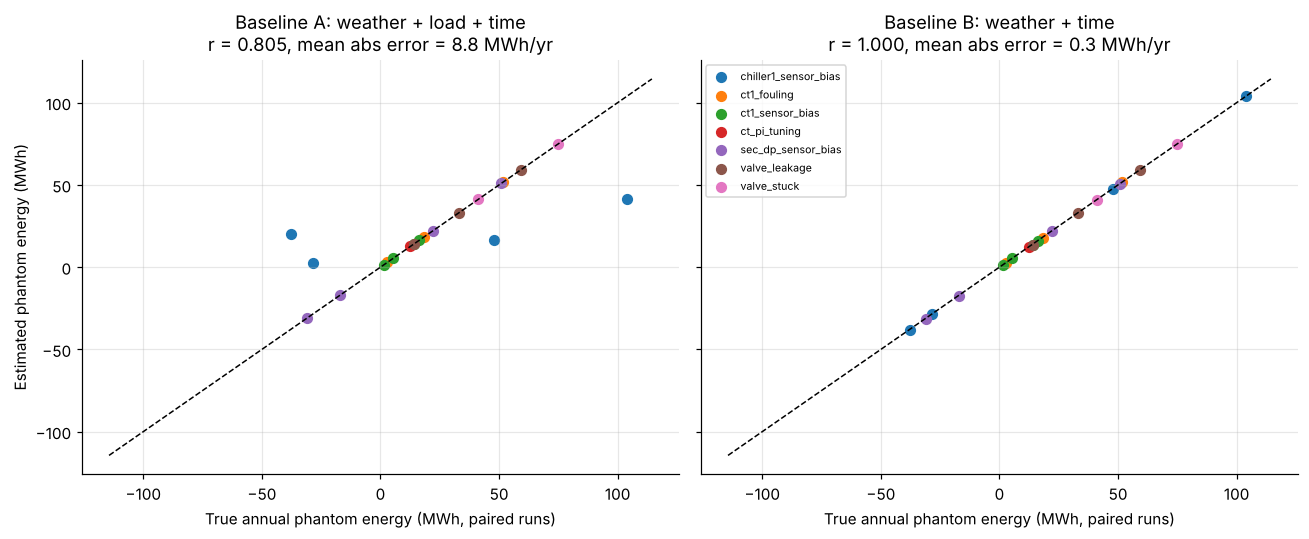

Worst estimates with baseline A (load-conditioned):
                            file   true_MWh  est_MWh
 ChillerPlant_chiller_bias_2.csv 104.000000     41.6
ChillerPlant_chiller_bias_-2.csv -37.799999     20.3
 ChillerPlant_chiller_bias_1.csv  48.000000     16.3
ChillerPlant_chiller_bias_-1.csv -28.500000      2.3


In [15]:
for k in runs:   # 24-h running means capture the building's thermal lag
    runs[k]["df"]["OA24"] = runs[k]["df"].OA_TEMP.rolling(96, min_periods=1).mean()
    runs[k]["df"]["WB24"] = runs[k]["df"].OA_TEMP_WB.rolling(96, min_periods=1).mean()
ff = runs[FF]["df"]; trn = ff[ff.PLANT_ON & TRAIN]
BASELINES = {"A: weather + load + time": ["OA_TEMP", "OA_TEMP_WB", "LOAD_TR", "HOUR", "DOW"],
             "B: weather + time": ["OA_TEMP", "OA_TEMP_WB", "OA24", "WB24", "HOUR", "DOW"]}
fitted = {}
v = ff[ff.PLANT_ON & VAL]
for name, cols_ in BASELINES.items():
    m = lgb.LGBMRegressor(n_estimators=400, learning_rate=.05, num_leaves=31, random_state=SEED, verbose=-1).fit(trn[cols_], trn.P_PLANT)
    hr = pd.DataFrame({"y": v.P_PLANT, "p": m.predict(v[cols_])}).resample("1h").mean().dropna()
    cv = np.sqrt(((hr.y - hr.p)**2).mean()) / hr.y.mean(); nmbe = (hr.y - hr.p).sum() / hr.y.sum()
    fitted[name] = m
    print(f"Baseline {name:26s} hourly CV(RMSE) = {cv:5.1%}, NMBE = {nmbe:+.2%} -> "
          f"{'meets' if cv < .3 and abs(nmbe) < .1 else 'fails'} ASHRAE Guideline 14")

MASK = ff.PLANT_ON   # score every run over the same operating intervals
def phantom(d, name):
    cols_ = BASELINES[name]; o = d[MASK.reindex(d.index).fillna(False)].copy()
    o["P_BASE"] = fitted[name].predict(o[cols_]); o["PHANTOM_KW"] = o.P_PLANT - o.P_BASE
    return o
# the model's own (small) fault-free bias over the year is subtracted so estimates are centred
FF_BIAS = {n: phantom(ff, n).PHANTOM_KW.sum() * .25 for n in BASELINES}
rows = []
for k, v in runs.items():
    if v["fault"] == "fault_free": continue
    true = (v["df"].P_PLANT - ff.P_PLANT)[MASK].sum() * .25
    for n in BASELINES:
        rows.append(dict(file=k, fault=v["fault"], sev=v["sev"], baseline=n, true_MWh=true / 1e3,
                         est_MWh=(phantom(v["df"], n).PHANTOM_KW.sum() * .25 - FF_BIAS[n]) / 1e3))
cmp = pd.DataFrame(rows)
fig, ax = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)
lim = cmp[["true_MWh", "est_MWh"]].abs().max().max() * 1.1
for a, (n, g) in zip(ax, cmp.groupby("baseline")):
    for f, gg in g.groupby("fault"): a.scatter(gg.true_MWh, gg.est_MWh, label=f, s=40)
    a.plot([-lim, lim], [-lim, lim], "k--", lw=1)
    r = np.corrcoef(g.true_MWh, g.est_MWh)[0, 1]; mae = (g.est_MWh - g.true_MWh).abs().mean()
    a.set(title=f"Baseline {n}\nr = {r:.3f}, mean abs error = {mae:.1f} MWh/yr", xlabel="True annual phantom energy (MWh, paired runs)")
ax[0].set_ylabel("Estimated phantom energy (MWh)"); ax[1].legend(fontsize=7); plt.tight_layout(); plt.show()
BASE = "B: weather + time"   # used for the tickets below
# NOTE: on the LBNL design every run shares the same weather and building schedule, so weather/schedule noise cancels in the
# annual totals and agreement is tighter than it would be on a live plant, where a week of data gives a noisier estimate.
print("Worst estimates with baseline A (load-conditioned):")
print(cmp[cmp.baseline.str.startswith("A")].assign(err=lambda x: x.est_MWh - x.true_MWh)
      .sort_values("err", key=abs, ascending=False).head(4)[["file", "true_MWh", "est_MWh"]].round(1).to_string(index=False))

## 7. Output: a ranked maintenance ticket list
For each faulty run we simulate what the tool would hand an operator after one week of running: the isolated equipment, the diagnosed fault type, the phantom kW/TR, ₹/day, and a payback estimate. Energy-saving faults are flagged as **comfort risk** (warmer chilled water / starved coils), not dropped.

In [16]:
ACTION = {"chiller1_sensor_bias": "Recalibrate/replace Chiller-1 CHW leaving-temperature sensor; check against header sensor",
          "ct1_sensor_bias": "Recalibrate Cooling-Tower-1 leaving-water sensor; compare against CDW supply header",
          "ct1_fouling": "Clean Cooling-Tower-1 fill/heat-exchange surface; check water treatment",
          "sec_dp_sensor_bias": "Recalibrate secondary-loop DP transmitter; verify pump speed vs flow curve",
          "valve_leakage": "Inspect condenser 3-way bypass valve seat; reset minimum position",
          "valve_stuck": "Free/replace condenser 3-way valve actuator; verify stroke",
          "ct_pi_tuning": "Retune tower-fan PI loop (lower gain / longer integral time)"}
tickets = []
N_DAYS_ON = ff.PLANT_ON.groupby(ff.index.date).any().sum()
for k, v in runs.items():
    if v["fault"] == "fault_free": continue
    ev = EV[(EV.file == k) & EV.detected]
    pg = P_graph[P_graph.file == k]
    diag = pg.pred.mode().iat[0] if len(pg) else "unknown"
    conf = (pg.pred == diag).mean() if len(pg) else 0
    root = ev.root.mode().iat[0] if len(ev) else "not detected"
    o = phantom(v["df"], BASE)
    phantom_kwh = o.PHANTOM_KW.sum() * .25 - FF_BIAS[BASE]
    inr_day = phantom_kwh / N_DAYS_ON * TARIFF_INR_PER_KWH
    kwtr = phantom_kwh / (o.LOAD_TR.sum() * .25)          # extra kWh per TR-h = average phantom kW/TR
    sup_shift = (v["df"].CWL_SEC_SW_TEMP - ff.CWL_SEC_SW_TEMP)[ff.PLANT_ON].mean()
    tickets.append(dict(run=k.replace("ChillerPlant_", "").replace(".csv", ""), true_fault=v["fault"], severity=v["sev"],
                        root_equipment=root, diagnosed_fault=diag, diag_confidence=conf,
                        phantom_kW_per_TR=kwtr, INR_per_day=inr_day, INR_per_year=phantom_kwh * TARIFF_INR_PER_KWH,
                        payback_days=(REPAIR_COST_INR.get(diag, 20000) / inr_day) if inr_day > 0 else np.nan,
                        flag=("ENERGY" if inr_day > 0 else "COMFORT RISK") + (" + warmer CHW" if sup_shift > .5 else ""),
                        action=ACTION.get(diag, "Inspect")))
T = pd.DataFrame(tickets).sort_values("INR_per_day", ascending=False).reset_index(drop=True)
T.index += 1
T.style.format({"severity": "{:g}", "diag_confidence": "{:.0%}", "phantom_kW_per_TR": "{:+.3f}", "INR_per_day": "₹{:,.0f}",
                "INR_per_year": "₹{:,.0f}", "payback_days": "{:,.0f}"}).background_gradient(subset=["INR_per_day"], cmap="Reds")

,run,true_fault,severity,root_equipment,diagnosed_fault,diag_confidence,phantom_kW_per_TR,INR_per_day,INR_per_year,payback_days,flag,action
1,chiller_bias_2,chiller1_sensor_bias,2,Chiller1,chiller1_sensor_bias,99%,+0.063,"₹3,013","₹933,975",2,ENERGY,Recalibrate/replace Chiller-1 CHW leaving-temperature sensor; check against header sensor
2,bypass_stuck_075,valve_stuck,0.75,CDW_Bypass_Valve,valve_stuck,54%,+0.048,"₹2,173","₹673,638",16,ENERGY,Free/replace condenser 3-way valve actuator; verify stroke
3,bypass_leakage_075,valve_leakage,0.75,CDW_Bypass_Valve,valve_stuck,65%,+0.038,"₹1,710","₹530,113",20,ENERGY,Free/replace condenser 3-way valve actuator; verify stroke
4,coolingtower_fouling_065,ct1_fouling,0.65,CT2,ct1_fouling,80%,+0.033,"₹1,502","₹465,728",40,ENERGY,Clean Cooling-Tower-1 fill/heat-exchange surface; check water treatment
5,secondary_chilled_water_pressure_bias_-020,sec_dp_sensor_bias,-0.2,CHW_Sec_Pumps,sec_dp_sensor_bias,100%,+0.033,"₹1,469","₹455,294",5,ENERGY,Recalibrate secondary-loop DP transmitter; verify pump speed vs flow curve
6,chiller_bias_1,chiller1_sensor_bias,1,Chiller1,chiller1_sensor_bias,94%,+0.030,"₹1,382","₹428,366",4,ENERGY,Recalibrate/replace Chiller-1 CHW leaving-temperature sensor; check against header sensor
7,bypass_stuck_050,valve_stuck,0.5,CDW_Bypass_Valve,valve_stuck,67%,+0.026,"₹1,184","₹367,074",30,ENERGY,Free/replace condenser 3-way valve actuator; verify stroke
8,bypass_leakage_050,valve_leakage,0.5,CDW_Bypass_Valve,valve_leakage,59%,+0.021,₹952,"₹295,167",47,ENERGY,Inspect condenser 3-way bypass valve seat; reset minimum position
9,secondary_chilled_water_pressure_bias_-010,sec_dp_sensor_bias,-0.1,CHW_Sec_Pumps,sec_dp_sensor_bias,100%,+0.014,₹632,"₹196,058",13,ENERGY,Recalibrate secondary-loop DP transmitter; verify pump speed vs flow curve
10,coolingtower_fouling_080,ct1_fouling,0.8,CT1,ct1_fouling,68%,+0.012,₹523,"₹162,145",115,ENERGY,Clean Cooling-Tower-1 fill/heat-exchange surface; check water treatment


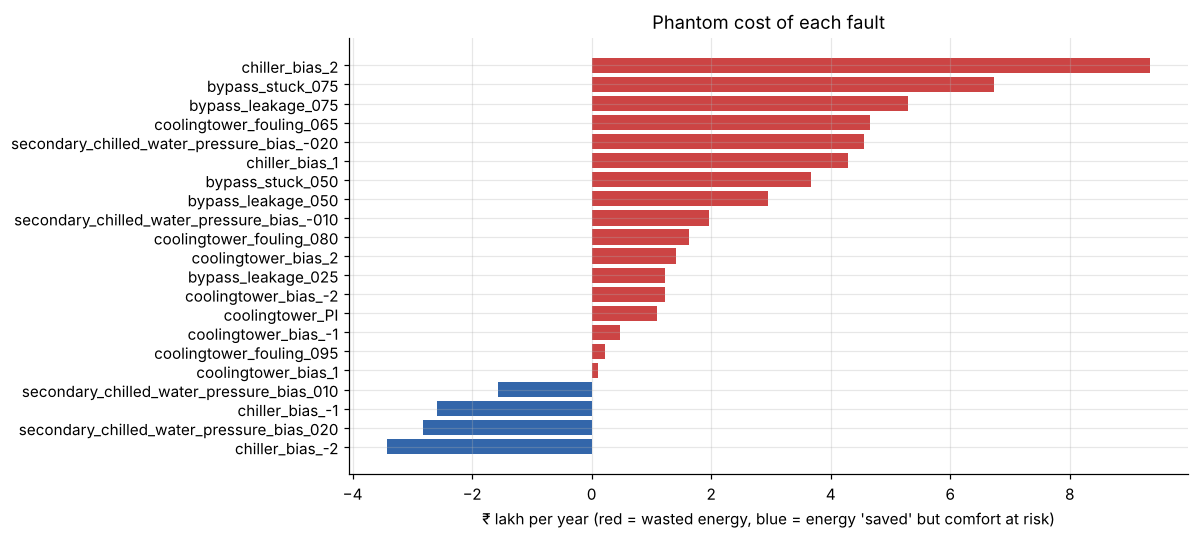

saved model_A_ticket_list.csv


In [17]:
fig, ax = plt.subplots(figsize=(11, 5))
t = T.sort_values("INR_per_year")
ax.barh(t.run, t.INR_per_year / 1e5, color=np.where(t.INR_per_year > 0, "#cc4444", "#3366aa"))
ax.set(xlabel="₹ lakh per year (red = wasted energy, blue = energy 'saved' but comfort at risk)", title="Phantom cost of each fault")
plt.tight_layout(); plt.show()
T.to_csv("model_A_ticket_list.csv", index_label="rank"); print("saved model_A_ticket_list.csv")

## 8. Findings, recommended actions and limits

**What the pipeline delivers to an operator**
1. **One ticket instead of a wall of alarms** — the flat detector lights up many sensors per fault day (Section 5); graph isolation names one piece of equipment.
2. **Sensor faults are separated from equipment faults** — a biased sensor breaks its own node's redundancy (energy/mixing balance) while real degradation (fouling) does not; the residual signature makes the two distinguishable, even at severities never seen in training.
3. **Every ticket carries a price** — phantom kW/TR and ₹/day from a weather-and-time baseline that meets ASHRAE Guideline 14 on fault-free data and tracks the paired ground truth. Conditioning the baseline on *measured load* was shown to hide much of the chiller-sensor penalty, because that fault changes the load itself.
4. **Actionable ranking** — repair the items with the largest ₹/day and shortest payback first; treat negative-cost faults as comfort/humidity tickets.

**Typical actions this ranking leads to:** recalibrate the Chiller-1 CHW sensor and the secondary DP transmitter (cheap, fast payback), repair/reset the condenser bypass valve, schedule tower-1 cleaning when the fouling penalty exceeds the cleaning cost, retune the tower-fan PI loop.

**Limitations**
* The LBNL data are simulated (EnergyPlus + Modelica, Chicago TMY); real plants add sensor noise, drift and missing data.
* Each faulty run contains one fault for the whole year, so evaluation is per day of a known-faulty run, not fault *onset* timing.
* Mild faults (e.g. −1 °C tower sensor, 95 % fouling) have small residuals and are detected less often — this is expected and should be read as "not worth a truck roll" rather than a model failure.
* Tariff and repair costs are placeholders; plug in the site's HT tariff and vendor quotes.